<a href="https://colab.research.google.com/github/JacintaOsoro/NNs-and-SIMILIAR-MODELS-GROUP-8/blob/NLP/NLP_summative.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EcoSort Waste Management Assistant
# Module 8 Summative Lab

## Overview

You are a data scientist at "EcoSort," a technology company that specializes in developing AI solutions for waste management. EcoSort has partnered with Metro City's waste management department to develop an intelligent waste management assistant that can help residents properly dispose of waste items so less time is spent sorting material at facilities.

This assistant needs to:

1. Identify waste materials from images uploaded by residents (CNN)
2. Classify waste items based on text descriptions provided by residents (RNN/Transformer)
3. Generate specific recycling instructions based on identified waste type and city policies (Generative Transformer with RAG)

Your task is to build this integrated system using the RealWaste dataset along with generated text data that simulates real-world waste management operations.

## Part 1: Dataset Exploration and Preparation

In this section, you will explore and prepare the datasets for your models.

### 1.1 Load and Explore the RealWaste Dataset

In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import nltk
import re
import string
import seaborn as sns
from collections import Counter

from nltk.tokenize import word_tokenize,sent_tokenize, RegexpTokenizer
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer,WordNetLemmatizer, SnowballStemmer
from nltk.probability import FreqDist
from nltk import pos_tag
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.util import ngrams
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('vader_lexicon')

import torch
import pandas as pd
import numpy as np
from transformers import AutoModelForCausalLM,AutoTokenizer
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity




import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Conv2D,Flatten,MaxPooling2D
from tensorflow.keras.utils import to_categorical

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
np.random.seed(42)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


###REAL WASTE DATASET

In [ ]:
# TODO: Load and explore the RealWaste dataset
# - Dataset structure
# - Distribution of waste categories
# - Image characteristics (resolution, quality, background)

# Your code here
#loading of the datasets




In [ ]:
#image characteristics


### 1.2 Explore Text Datasets

##WASTE DESCRIPTION DATASET

In [7]:
# TODO: Load and explore the waste description text data
# - Load waste_descriptions.csv
# - Analyze vocabulary and structure
# - Understand the distribution of categories

# Your code here
# df_description = pd.read_csv('waste_descriptions.csv')
# df_description
df_description = pd.read_csv('/content/waste_descriptions.csv')
df_description

,description,category,disposal_instruction,common_confusion,material_composition
0,soiled silver tablecloth,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
1,folded glass bottle leaking,Glass,"Remove caps, lids, and corks before recycling.",NaN,"Silica-based material, may contain additives f..."
2,large Supermarket vegetable waste with food re...,Food Organics,"If no compost available, place in general waste.",NaN,Biodegradable matter derived from plant or ani...
3,intact floral carpet piece,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
4,empty fun-sized purple apple core,Food Organics,Keep separate from recyclable materials.,Meat and dairy products may be restricted in s...,Biodegradable matter derived from plant or ani...
...,...,...,...,...,...
4995,new red tea bags,Food Organics,Keep separate from recyclable materials.,NaN,Biodegradable matter derived from plant or ani...
4996,torn white disposable diaper sealed,Miscellaneous Trash,Hazardous items like batteries require special...,NaN,Various non-recyclable materials often with mi...
4997,broken mini apple core,Food Organics,Place in organic waste or compost bin.,Meat and dairy products may be restricted in s...,Biodegradable matter derived from plant or ani...
4998,pink glass pitcher with food residue,Glass,"Place in glass recycling bin, sorted by color ...","Window glass, drinking glasses, and ceramics s...","Silica-based material, may contain additives f..."


####Analyzing Vocabulary and Structure for Waste Description Dataset


In [ ]:
#Checking shape of the dataset
print(df_description.shape)

(5000, 5)


In [ ]:
#Checking the column names
print(df_description.columns)

Index(['description', 'category', 'disposal_instruction', 'common_confusion',
       'material_composition'],
      dtype='object')


In [ ]:
#Knowing the overall info about the dataset
print(df_description.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   description           5000 non-null   object
 1   category              5000 non-null   object
 2   disposal_instruction  5000 non-null   object
 3   common_confusion      2496 non-null   object
 4   material_composition  5000 non-null   object
dtypes: object(5)
memory usage: 195.4+ KB
None


In [ ]:
#Checking for missing values
print(df_description.isnull().sum())

description                0
category                   0
disposal_instruction       0
common_confusion        2504
material_composition       0
dtype: int64


###Understanding the distribution of categories for Waste Description Dataset

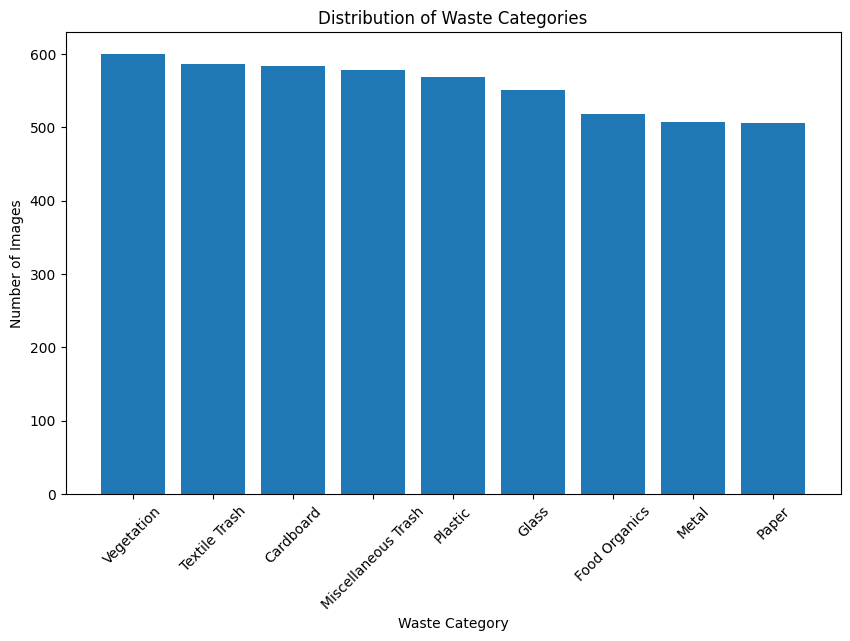

In [ ]:
# understand the distribution of  categories
category_counts = df_description['category'].value_counts()
plt.figure(figsize=(10,6))
plt.bar(category_counts.index,category_counts.values)
plt.xticks(rotation=45)
plt.xlabel('Waste Category')
plt.ylabel('Number of Images')
plt.title('Distribution of Waste Categories')
plt.show()

#WASTE POLICY DOCUMENTS DATASET

In [8]:
# TODO: Load and explore the waste policy documents
# - Load waste_policy_documents.csv
# - Understand document organization and language

# Your code here
# df_policy_documents =  pd.read_json('waste_policy_documents.json')
# df_policy_documents
df_policy_documents = pd.read_json('/content/waste_policy_documents.json')
df_policy_documents

,policy_id,policy_type,categories_covered,effective_date,document_text,jurisdiction
0,1,Textile Trash Recycling Guidelines,[Textile Trash],2023-11-04,TEXTILE RECYCLING GUIDELINES\n\nAcceptable Ite...,Metro City
1,2,Glass Recycling Guidelines,[Glass],2023-01-24,GLASS RECYCLING GUIDELINES\n\nAcceptable Items...,Metro City
2,3,Food Organics Recycling Guidelines,[Food Organics],2023-05-08,FOOD ORGANICS RECYCLING GUIDELINES\n\nAcceptab...,Metro City
3,4,Plastic Recycling Guidelines,[Plastic],2023-04-05,PLASTIC RECYCLING GUIDELINES\n\nAcceptable Ite...,Metro City
4,5,Vegetation Recycling Guidelines,[Vegetation],2023-12-04,VEGETATION RECYCLING GUIDELINES\n\nAcceptable ...,Metro City
5,6,Cardboard Recycling Guidelines,[Cardboard],2023-11-24,CARDBOARD RECYCLING GUIDELINES\n\nAcceptable I...,Metro City
6,7,Metal Recycling Guidelines,[Metal],2023-09-03,METAL RECYCLING GUIDELINES\n\nAcceptable Items...,Metro City
7,8,Paper Recycling Guidelines,[Paper],2023-10-14,PAPER RECYCLING GUIDELINES\n\nAcceptable Items...,Metro City
8,9,Miscellaneous Trash Recycling Guidelines,[Miscellaneous Trash],2023-01-01,MISCELLANEOUS TRASH GUIDELINES\n\nItems That C...,Metro City
9,10,Municipal Waste Guidelines,"[Plastic, Miscellaneous Trash, Vegetation]",2023-10-01,MUNICIPAL WASTE GUIDELINES\n\nGENERAL REQUIREM...,Metro City


In [ ]:
#Checking the shape of the dataset
print(df_policy_documents.shape)

(14, 6)


In [ ]:
#Understanding document organization an language

print(df_policy_documents.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   policy_id           14 non-null     int64 
 1   policy_type         14 non-null     object
 2   categories_covered  14 non-null     object
 3   effective_date      14 non-null     object
 4   document_text       14 non-null     object
 5   jurisdiction        14 non-null     object
dtypes: int64(1), object(5)
memory usage: 804.0+ bytes
None


In [ ]:
#checking the column names
print(df_policy_documents.columns)

Index(['policy_id', 'policy_type', 'categories_covered', 'effective_date',
       'document_text', 'jurisdiction'],
      dtype='object')


In [ ]:
#Checking the datatypes for each column
print(df_policy_documents.dtypes)

policy_id              int64
policy_type           object
categories_covered    object
effective_date        object
document_text         object
jurisdiction          object
dtype: object


In [7]:
#Checking if there are duplicates
df_policy_documents.duplicated().sum()

TypeError: unhashable type: 'list'

### 1.3 Create Data Pipelines

### 1.3 Create Data Pipelines

This section creates the data pipeline required to prepare the waste-description and policy-document datasets for modelling.

The pipeline performs the following activities:

- Combines the relevant text fields into one consolidated text field.
- Cleans and standardises the text.
- Removes URLs, email addresses, numbers, punctuation, and unnecessary spaces.
- Splits the labelled waste-description data into training and testing datasets.
- Converts the cleaned text into numerical embeddings using the `all-MiniLM-L6-v2` SentenceTransformer model.
- Saves the generated embeddings for later analysis or modelling.

In [11]:
from sentence_transformers import SentenceTransformer

In [23]:
# ==========================================================
# 1.3 CREATE DATA PIPELINES
# ==========================================================
# This pipeline:
# 1. Combines the relevant text columns.
# 2. Cleans and standardises the text.
# 3. Splits the labelled data into training and test sets.
# 4. Generates numerical text embeddings.
# 5. Saves the embeddings as CSV files.
import re
import string
import pandas as pd
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer

# ==========================================================
# TEXT CLEANING FUNCTION
# ==========================================================
# Convert each text value to lowercase and remove:
# - Website links
# - Email addresses
# - Numbers
# - Punctuation
# - Repeated or unnecessary spaces

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\S+@\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text
# ==========================================================
# COMBINE WASTE-DESCRIPTION TEXT FIELDS
# ==========================================================
# Combine the waste description, disposal instruction,
# common confusion, and material composition fields.
# Missing values are replaced with blank text.

df_description["combined_text"] = (
    df_description["description"].fillna("") + " " +
    df_description["disposal_instruction"].fillna("") + " " +
    df_description["common_confusion"].fillna("") + " " +
    df_description["material_composition"].fillna("")
)
# ==========================================================
# COMBINE POLICY-DOCUMENT TEXT FIELDS
# ==========================================================
# Combine the policy type, covered categories, document text,
# and jurisdiction into one field for each policy document.

df_policy_documents["combined_text"] = (
    df_policy_documents["policy_type"].fillna("") + " " +
    df_policy_documents["categories_covered"].fillna("").astype(str) + " " +
    df_policy_documents["document_text"].fillna("") + " " +
    df_policy_documents["jurisdiction"].fillna("")
)

# ==========================================================
# APPLY CLEANING TO CREATE clean_text COLUMNS
# ==========================================================
df_description["clean_text"] = df_description["combined_text"].apply(clean_text)
df_policy_documents["clean_text"] = df_policy_documents["combined_text"].apply(clean_text)

# ==========================================================
# SPLIT LABELLED DATA INTO TRAINING AND TEST SETS
# ==========================================================
# Use 80% of the waste-description records for training and
# 20% for testing.
#
# Stratification maintains approximately the same category
# distribution in both datasets.
#
# random_state=42 makes the split reproducible.

train_desc, test_desc = train_test_split(
    df_description,
    test_size=0.20,
    random_state=42,
    stratify=df_description["category"]
)
# ==========================================================
# LOAD SENTENCE TRANSFORMER EMBEDDING MODEL
# ==========================================================
# all-MiniLM-L6-v2 converts each cleaned text record into a
# fixed-length numerical vector that represents its meaning.

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
# ==========================================================
# GENERATE TEXT EMBEDDINGS
# ==========================================================
# Generate embeddings separately for waste descriptions
# and policy-document text.

description_embeddings = embedding_model.encode(
    df_description["clean_text"].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True
)

policy_embeddings = embedding_model.encode(
    df_policy_documents["clean_text"].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

## Part 2: Waste Material Classification with CNN

In this section, you will build a CNN model to classify waste materials from images.

### 2.1 Preprocess Images

In [ ]:
# TODO: Implement image preprocessing
# - Apply the preprocessing pipeline created earlier

# Your code here

### 2.2 Implement CNN Model with Transfer Learning

In [ ]:
# TODO: Select an appropriate base model and implement transfer learning
# - Choose from MobileNet, EfficientNet, etc.
# - Add custom classification layers for the 9 waste categories
# - Configure loss function and metrics

# Your code here

### 2.3 Train and Evaluate the Model

In [ ]:
# TODO: Train the CNN model
# - Use appropriate batch size and epochs
# - Implement regularization to prevent overfitting
# - Monitor training and validation metrics

# Your code here

In [ ]:
# TODO: Evaluate model performance
# - Calculate accuracy on test set
# - Generate confusion matrix
# - Analyze error patterns

# Your code here

### 2.4 Fine-tune the Model

In [ ]:
# TODO: Tune model parameters to improve performance
# - Adjust learning rate
# - Add regularization, dropout
# - Modify architecture if needed

# Your code here

## Part 3: Waste Description Classification

In this section, you will build a text classification model to categorize waste based on descriptions.

### 3.1 Preprocess Text Data

This section prepares the labelled waste-description dataset for training the text-classification model.

The preprocessing process includes:

1. Loading the waste-description CSV file.
2. Identifying the text-description and category columns.
3. Removing records with missing or empty descriptions and categories.
4. Standardising unnecessary whitespace.
5. Removing exact duplicate description-category pairs.
6. Encoding the waste categories as numerical labels.
7. Splitting the data into training, validation, and test datasets.
8. Tokenising the descriptions using the DistilBERT tokenizer.

The dataset is divided as follows:

- **70% training data:** Used to train the model.
- **15% validation data:** Used to monitor performance during training and select the best model.
- **15% test data:** Used for the final independent evaluation.


In [13]:
# ==========================================================
# 3.1 PREPROCESS TEXT DATA
# ==========================================================
# This section:
# 1. Loads the labelled waste-description dataset.
# 2. Identifies the text and category columns.
# 3. Removes missing, empty, and duplicate records.
# 4. Encodes category names as numerical labels.
# 5. Creates the training, validation, and test datasets.
# 6. Tokenises the descriptions for DistilBERT.
# ------------------------------------------------------------
# CLEAN AND VALIDATE THE DATASET
# ------------------------------------------------------------
# Retain only the detected text and category columns,
# then rename them to standard names used by the model.

# Define necessary variables for this preprocessing step
SEED = 42 # Standard seed for reproducibility
TEXT_COLUMN = "clean_text" # Using the cleaned text column from df_description
LABEL_COLUMN = "category" # The category column in df_description

# Use df_description which is already loaded and processed in previous steps
data = df_description[[TEXT_COLUMN, LABEL_COLUMN]].copy()
data.columns = ["text", "label"]

# Remove records with missing descriptions or categories.
data = data.dropna(subset=["text", "label"])

# Convert the values to strings, remove repeated spaces,
# and remove spaces at the beginning and end.
data["text"] = (
    data["text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

data["label"] = (
    data["label"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Remove records containing blank descriptions or categories.
data = data[
    (data["text"].str.len() > 0) &
    (data["label"].str.len() > 0)
].copy()

# Remove exact duplicate description-category combinations.
data = data.drop_duplicates(
    subset=["text", "label"]
).reset_index(drop=True)
# ------------------------------------------------------------
# ENCODE CATEGORY LABELS
# ------------------------------------------------------------
# DistilBERT requires numerical target labels.
# Assign a unique integer to every waste category.

class_names = sorted(data["label"].unique().tolist())

label_to_id = {
    label: index
    for index, label in enumerate(class_names)
}

id_to_label = {
    index: label
    for label, index in label_to_id.items()
}

data["label_id"] = data["label"].map(label_to_id)
NUM_LABELS = len(class_names)
# ------------------------------------------------------------
# SPLIT DATA INTO TRAINING, VALIDATION, AND TEST SETS
# ------------------------------------------------------------
# First split:
# - 70% becomes training data.
# - 30% becomes temporary data.
#
# Second split:
# - Half of the temporary data becomes validation data.
# - Half becomes test data.
#
# Final approximate split: 70% training, 15% validation,
# and 15% testing.
# ------------------------------------------------------------
# TOKENISE THE TEXT DESCRIPTIONS
# ------------------------------------------------------------
# The DistilBERT tokenizer:
# - Breaks each description into subword tokens.
# - Converts the tokens into numerical token IDs.
# - Truncates descriptions that exceed MAX_LENGTH.
# - Pads shorter descriptions to MAX_LENGTH.
# - Creates the attention mask used by DistilBERT.

In [14]:
# ==========================================================
# TEXT PREPROCESSING PIPELINE
# ==========================================================

!pip install -q sentence-transformers

import pandas as pd
import numpy as np
import re
import string

from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer

# ==========================================================
# TEXT CLEANING FUNCTION
# ==========================================================

def clean_text(text):

    text = str(text).lower()

    # remove urls
    text = re.sub(r'http\S+|www\S+', '', text)

    # remove emails
    text = re.sub(r'\S+@\S+', '', text)

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# ==========================================================
# COMBINE WASTE DESCRIPTION FIELDS
# ==========================================================

df_description["combined_text"] = (
    df_description["description"].fillna("") + " " +
    df_description["disposal_instruction"].fillna("") + " " +
    df_description["common_confusion"].fillna("") + " " +
    df_description["material_composition"].fillna("")
)

# ==========================================================
# COMBINE POLICY DOCUMENT FIELDS
# ==========================================================

df_policy_documents["combined_text"] = (
    df_policy_documents["policy_type"].fillna("") + " " +
    df_policy_documents["categories_covered"].astype(str).fillna("") + " " +
    df_policy_documents["document_text"].fillna("") + " " +
    df_policy_documents["jurisdiction"].fillna("")
)

# ==========================================================
# APPLY CLEANING
# ==========================================================

df_description["clean_text"] = (
    df_description["combined_text"]
    .apply(clean_text)
)

df_policy_documents["clean_text"] = (
    df_policy_documents["combined_text"]
    .apply(clean_text)
)

# ==========================================================
# TOKENIZATION
# ==========================================================

df_description["tokens"] = (
    df_description["clean_text"]
    .apply(lambda x: x.split())
)

df_policy_documents["tokens"] = (
    df_policy_documents["clean_text"]
    .apply(lambda x: x.split())
)

# ==========================================================
# TRAIN / TEST SPLIT
# ==========================================================

train_desc, test_desc = train_test_split(
    df_description,
    test_size=0.20,
    random_state=42,
    stratify=df_description["category"]
)

train_policy, test_policy = train_test_split(
    df_policy_documents,
    test_size=0.20,
    random_state=42
)

# ==========================================================
# SENTENCE TRANSFORMER EMBEDDINGS
# ==========================================================

model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

description_embeddings = model.encode(
    df_description["clean_text"].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True
)

policy_embeddings = model.encode(
    df_policy_documents["clean_text"].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True
)

# ==========================================================
# SAVE EMBEDDINGS TO DATAFRAMES
# ==========================================================

description_embedding_df = pd.DataFrame(
    description_embeddings
)

description_embedding_df.insert(
    0,
    "category",
    df_description["category"]
)

policy_embedding_df = pd.DataFrame(
    policy_embeddings
)

policy_embedding_df.insert(
    0,
    "policy_id",
    df_policy_documents["policy_id"]
)

# ==========================================================
# SUMMARY
# ==========================================================

print("========== TEXT PREPROCESSING COMPLETE ==========")

print("\nDescription Records:", len(df_description))
print("Policy Documents:", len(df_policy_documents))

print("\nDescription Embeddings Shape:")
print(description_embeddings.shape)

print("\nPolicy Embeddings Shape:")
print(policy_embeddings.shape)

print("\nEmbedding Dimension:")
print(description_embeddings.shape[1])

print("\nTrain Description Records:", len(train_desc))
print("Test Description Records:", len(test_desc))

print("\nSample Processed Description:")
print(df_description["clean_text"].iloc[0][:500])

print("\nSample Tokens:")
print(df_description["tokens"].iloc[0][:20])

print("\nPreprocessed data ready for:")
print("- Semantic Search")
print("- RAG")
print("- Policy Recommendation")
print("- Waste Classification")
print("- Similarity Matching")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

========== TEXT PREPROCESSING COMPLETE ==========

Description Records: 5000
Policy Documents: 14

Description Embeddings Shape:
(5000, 384)

Policy Embeddings Shape:
(14, 384)

Embedding Dimension:
384

Train Description Records: 4000
Test Description Records: 1000

Sample Processed Description:
soiled silver tablecloth look for textile recycling programs in your area fabric made from natural or synthetic fibers may include blends

Sample Tokens:
['soiled', 'silver', 'tablecloth', 'look', 'for', 'textile', 'recycling', 'programs', 'in', 'your', 'area', 'fabric', 'made', 'from', 'natural', 'or', 'synthetic', 'fibers', 'may', 'include']

Preprocessed data ready for:
- Semantic Search
- RAG
- Policy Recommendation
- Waste Classification
- Similarity Matching


### 3.2 Implement Text Classification Model

This section implements a transformer-based text-classification model using **DistilBERT**.

`distilbert-base-uncased` is loaded as a pretrained language model and adapted to predict the waste categories in the dataset. The model receives the tokenised waste descriptions and produces a probability for each possible category.

All pretrained DistilBERT layers are left trainable. This allows the model to fine-tune its existing language knowledge to the waste-classification task.

The implementation includes:

- Loading the pretrained DistilBERT tokenizer.
- Creating a custom PyTorch dataset.
- Creating training, validation, and test data loaders.
- Loading DistilBERT for sequence classification.
- Configuring the output layer using the number of waste categories.
- Configuring the AdamW optimiser and learning-rate scheduler.

In [17]:
from tqdm.auto import tqdm

In [15]:
# ==========================================================
# 3.2 IMPLEMENT THE DISTILBERT CLASSIFICATION MODEL
# ==========================================================
# This section:
# 1. Creates a PyTorch dataset for the tokenised descriptions.
# 2. Creates data loaders for model training and evaluation.
# 3. Loads pretrained DistilBERT.
# 4. Configures the model for the available waste categories.
# 5. Makes all model parameters trainable.
# 6. Configures the optimiser and learning-rate scheduler.

import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer, get_linear_schedule_with_warmup
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import pandas as pd # Import pandas here if not already imported in this cell's context

# Define configuration constants (derived from previously deleted configuration cell)
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128
BATCH_SIZE = 16
EPOCHS = 3
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------
# SPLIT DATA INTO TRAINING, VALIDATION, AND TEST SETS
# ------------------------------------------------------------
# First split:
# - 70% becomes training data.
# - 30% becomes temporary data.
#
# Second split:
# - Half of the temporary data becomes validation data.
# - Half becomes test data.
#
# Final approximate split: 70% training, 15% validation,
# and 15% testing.

# Assuming 'data' DataFrame, 'SEED', 'class_names', 'label_to_id' are available from previous cells
minimum_class_count = data["label"].value_counts().min()

use_stratification = minimum_class_count >= 3

if use_stratification:
    stratify_all = data["label_id"]
else:
    stratify_all = None
    print(
        "\nWARNING: Stratification has been disabled because at least one "
        "category has fewer than three records."
    )

train_df, temporary_df = train_test_split(
    data,
    test_size=0.30,
    random_state=SEED,
    stratify=stratify_all
)

temporary_minimum = temporary_df["label"].value_counts().min()

if use_stratification and temporary_minimum >= 2:
    temporary_stratify = temporary_df["label_id"]
else:
    temporary_stratify = None

validation_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temporary_stratify
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\nDataset split:")
print(f"Training records:   {len(train_df):,}")
print(f"Validation records: {len(validation_df):,}")
print(f"Test records:       {len(test_df):,}")
print(f"Total records:      {len(data):,}")

print("\nTraining category distribution:")
display(
    train_df["label"]
    .value_counts()
    .reindex(class_names, fill_value=0)
    .rename("training_records")
    .to_frame()
)

# ------------------------------------------------------------
# LOAD DISTILBERT TOKENIZER
# ------------------------------------------------------------
print(f"\nLoading tokenizer: {MODEL_NAME}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# ------------------------------------------------------------
# CREATE A PYTORCH DATASET
# ------------------------------------------------------------
# This class retrieves one description at a time, tokenises it,
# and returns the tensors required by DistilBERT:
# - input_ids
# - attention_mask
# - numerical category label
class WasteTextDataset(Dataset):

    def __init__(
        self,
        dataframe,
        tokenizer,
        max_length
    ):
        self.texts = dataframe["text"].tolist()
        self.labels = dataframe["label_id"].tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        text = str(self.texts[index])
        label = int(self.labels[index])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        item = {
            key: value.squeeze(0)
            for key, value in encoding.items()
        }

        item["labels"] = torch.tensor(
            label,
            dtype=torch.long
        )

        return item


train_dataset = WasteTextDataset(
    train_df,
    tokenizer,
    MAX_LENGTH
)

validation_dataset = WasteTextDataset(
    validation_df,
    tokenizer,
    MAX_LENGTH
)

test_dataset = WasteTextDataset(
    test_df,
    tokenizer,
    MAX_LENGTH
)

# ------------------------------------------------------------
# CREATE DATA LOADERS
# ------------------------------------------------------------
# Data loaders organise records into batches.
#
# Training data is shuffled during every epoch.
# Validation and test data are not shuffled because they are
# only used to evaluate the model.

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)


# ------------------------------------------------------------
# LOAD DISTILBERT FOR SEQUENCE CLASSIFICATION
# ------------------------------------------------------------
# The pretrained DistilBERT model is given a classification
# output layer corresponding to the number of waste categories.

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id_to_label,
    label2id=label_to_id,
    ignore_mismatched_sizes=True
)

# Move the model to the GPU when available.
model = model.to(DEVICE)

# Fine-tune all pretrained DistilBERT parameters.
for parameter in model.parameters():
    parameter.requires_grad = True

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"Total model parameters:     {total_parameters:,}")
print(f"Trainable parameters:       {trainable_parameters:,}")
print(
    "All pretrained layers trainable: "
    f"{total_parameters == trainable_parameters}"
)

# ------------------------------------------------------------
# CONFIGURE THE OPTIMISER AND LEARNING-RATE SCHEDULER
# ------------------------------------------------------------
# AdamW updates the model's trainable parameters.
#
# The scheduler gradually adjusts the learning rate during
# training. A 10% warm-up period is used to reduce unstable
# parameter updates at the beginning of training.

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

total_training_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.10 * total_training_steps),
    num_training_steps=total_training_steps
)


Dataset split:
Training records:   3,495
Validation records: 749
Test records:       749
Total records:      4,993

Training category distribution:


,training_records
label,
Cardboard,409
Food Organics,363
Glass,384
Metal,356
Miscellaneous Trash,405
Paper,354
Plastic,396
Textile Trash,410
Vegetation,418



Loading tokenizer: distilbert-base-uncased


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total model parameters:     66,960,393
Trainable parameters:       66,960,393
All pretrained layers trainable: True


### 3.3 Train and Evaluate the Model

This section trains and evaluates the DistilBERT text-classification model.

The model is trained using the configured batch size, learning rate, weight decay, and number of epochs. During every epoch, the training loss and accuracy are calculated. The model is then evaluated against the validation dataset.

The model version with the highest validation accuracy is retained for final evaluation.

The final evaluation includes:

- Training and validation loss.
- Training and validation accuracy.
- Test-set loss and accuracy.
- Precision, recall, and F1-score for each waste category.
- A confusion matrix showing correct and incorrect classifications.
- Analysis of common category-confusion patterns.
- Review of high-confidence errors.
- Review of descriptions with low prediction confidence.

In [19]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [25]:
# ==========================================================
# 3.3 TRAIN AND EVALUATE THE MODEL
# ==========================================================
# This section:
# 1. Trains all DistilBERT layers.
# 2. Monitors training and validation performance.
# 3. Retains the model with the best validation accuracy.
# 4. Evaluates the selected model on unseen test data.
# 5. Produces a classification report and confusion matrix.
# 6. Analyses prediction errors and low-confidence records.

from tqdm.auto import tqdm

# ------------------------------------------------------------
# MODEL EVALUATION FUNCTION
# ------------------------------------------------------------
# Evaluate the model without updating its parameters.
#
# The function returns:
# - Average loss
# - Accuracy
# - Predicted label IDs
# - Actual label IDs
# - Probability assigned to each category

def evaluate_model(
    model,
    data_loader,
    device
):
    model.eval()

    total_loss = 0.0
    predictions = []
    actual_labels = []
    probabilities = []

    with torch.no_grad():
        for batch in tqdm(
            data_loader,
            desc="Evaluating",
            leave=False
        ):
            batch = {
                key: value.to(device)
                for key, value in batch.items()
            }

            outputs = model(**batch)

            loss = outputs.loss
            logits = outputs.logits

            batch_probabilities = torch.softmax(
                logits,
                dim=1
            )

            batch_predictions = torch.argmax(
                batch_probabilities,
                dim=1
            )

            total_loss += loss.item()

            predictions.extend(
                batch_predictions.cpu().numpy()
            )

            actual_labels.extend(
                batch["labels"].cpu().numpy()
            )

            probabilities.extend(
                batch_probabilities.cpu().numpy()
            )

    average_loss = total_loss / max(len(data_loader), 1)

    accuracy = accuracy_score(
        actual_labels,
        predictions
    )

    return (
        average_loss,
        accuracy,
        np.array(predictions),
        np.array(actual_labels),
        np.array(probabilities)
    )

# ------------------------------------------------------------
# TRAIN ALL DISTILBERT LAYERS
# ------------------------------------------------------------
# For each epoch:
# 1. Set the model to training mode.
# 2. Process the training records in batches.
# 3. Calculate the classification loss.
# 4. Propagate the error backwards through the model.
# 5. Clip extreme gradients for training stability.
# 6. Update the model parameters and learning rate.
# 7. Measure validation performance.
# 8. Retain the best-performing model.

best_validation_accuracy = -1.0
best_model_state = None
training_history = []

print("\n" + "=" * 70)
print("MODEL TRAINING")
print("=" * 70)

# The scheduler needs `total_training_steps` which depends on `train_loader` and `EPOCHS`.
# These should be defined by now from previous cells, specifically 9KrHYgHWRjNb where DataLoaders are defined.

total_training_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.10 * total_training_steps),
    num_training_steps=total_training_steps
)

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0
    training_predictions = []
    training_labels = []

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{EPOCHS}"
    )

    for batch in progress_bar:

        batch = {
            key: value.to(DEVICE)
            for key, value in batch.items()
        }

        optimizer.zero_grad()

        outputs = model(**batch)

        loss = outputs.loss
        logits = outputs.logits

        loss.backward()

        # Prevent extreme gradient values.
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()
        scheduler.step()

        running_loss += loss.item()

        batch_predictions = torch.argmax(
            logits,
            dim=1
        )

        training_predictions.extend(
            batch_predictions.detach().cpu().numpy()
        )

        training_labels.extend(
            batch["labels"].detach().cpu().numpy()
        )

        progress_bar.set_postfix(
            batch_loss=f"{loss.item():.4f}"
        )

    training_loss = running_loss / max(len(train_loader), 1)

    training_accuracy = accuracy_score(
        training_labels,
        training_predictions
    )

    (
        validation_loss,
        validation_accuracy,
        _,
        _,
        _
    ) = evaluate_model(
        model,
        validation_loader,
        DEVICE
    )

    training_history.append({
        "epoch": epoch + 1,
        "training_loss": training_loss,
        "validation_loss": validation_loss,
        "training_accuracy": training_accuracy,
        "validation_accuracy": validation_accuracy
    })

    print(
        f"\nEpoch {epoch + 1}/{EPOCHS}"
        f"\n  Training loss:       {training_loss:.4f}"
        f"\n  Validation loss:     {validation_loss:.4f}"
        f"\n  Training accuracy:   {training_accuracy:.4f}"
        f"\n  Validation accuracy: {validation_accuracy:.4f}"
    )

    if validation_accuracy > best_validation_accuracy:
        best_validation_accuracy = validation_accuracy

        best_model_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }

        print("  Best model updated.")

# Restore the best validation model.
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    model = model.to(DEVICE)



MODEL TRAINING


Epoch 1/3:   0%|          | 0/219 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/47 [00:00<?, ?it/s]


Epoch 1/3
  Training loss:       0.0064
  Validation loss:     0.0026
  Training accuracy:   1.0000
  Validation accuracy: 1.0000
  Best model updated.


Epoch 2/3:   0%|          | 0/219 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x77fd90371080>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x77fd90371080>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/


Epoch 2/3
  Training loss:       0.0029
  Validation loss:     0.0016
  Training accuracy:   1.0000
  Validation accuracy: 1.0000


Epoch 3/3:   0%|          | 0/219 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/47 [00:00<?, ?it/s]


Epoch 3/3
  Training loss:       0.0022
  Validation loss:     0.0014
  Training accuracy:   1.0000
  Validation accuracy: 1.0000


In [19]:
# TODO: Train the text classification model
# - Use appropriate training parameters
# - Monitor training progress

# Your code here
# This cell originally contained the data splitting, tokenizer loading,
# WasteTextDataset class, and DataLoader creation. This code has been
# moved to cell G73WihMEORcy to ensure that `train_loader` and other
# variables are defined before being used in the training loop in F04HCQ9LORcz.
# Therefore, this cell is now intentionally left empty or can be removed if not needed for other purposes.

### 3.4 Create Classification Function

This section creates a reusable function named `classify_waste_description()`.

The function accepts a waste description as text and returns:

- The original cleaned description.
- The predicted waste category.
- The model's confidence in the prediction.
- The probability assigned to every category when requested.

The function validates the input, tokenises the description, applies the trained DistilBERT model, converts the model output into probabilities, and selects the category with the highest probability.

#### Example

```python
classify_waste_description(
    "An empty plastic water bottle"
)

In [27]:
# ==========================================================
# 3.4 CREATE THE WASTE CLASSIFICATION FUNCTION
# ==========================================================
# The function accepts a waste description and uses the trained
# DistilBERT model to predict its most likely waste category.


def classify_waste_description(
    description,
    return_all_probabilities=False
):
    """
    Classify a waste description into an appropriate category.

    Parameters
    ----------
    description : str
        Text description of the waste item.

    return_all_probabilities : bool, optional
        When True, return the probabilities assigned to all
        waste categories. The default is False.

    Returns
    -------
    dict
        A dictionary containing the cleaned description,
        predicted category, prediction confidence, and
        optionally the probability for every category.
    """

    # Validate that an input value has been provided.
    if description is None:
        raise ValueError(
            "The waste description cannot be None."
        )

    # Convert the input to text and standardise its spacing.
    clean_description = re.sub(
        r"\s+",
        " ",
        str(description)
    ).strip()

    # Reject blank descriptions.
    if not clean_description:
        raise ValueError(
            "Please provide a non-empty waste description."
        )

    # Set the model to evaluation mode.
    # This disables training-specific behaviour such as dropout.
    model.eval()

    # Tokenise the description using the same settings applied
    # when preparing the model's training data.
    encoded_input = tokenizer(
        clean_description,
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )

    # Move the tokenised input to the same device as the model.
    encoded_input = {
        key: value.to(DEVICE)
        for key, value in encoded_input.items()
    }

    # Generate a prediction without calculating gradients.
    with torch.no_grad():
        outputs = model(**encoded_input)

        # Convert the raw model scores into probabilities.
        probabilities = torch.softmax(
            outputs.logits,
            dim=1
        )[0].cpu().numpy()

    # Select the category with the highest probability.
    predicted_id = int(np.argmax(probabilities))
    predicted_category = id_to_label[predicted_id]
    confidence = float(probabilities[predicted_id])

    # Prepare the standard prediction output.
    prediction_result = {
        "description": clean_description,
        "predicted_category": predicted_category,
        "confidence": confidence
    }

    # Optionally include the probability assigned to every
    # available waste category.
    if return_all_probabilities:
        prediction_result["all_probabilities"] = {
            id_to_label[index]: float(probability)
            for index, probability in enumerate(probabilities)
        }

    return prediction_result

#### Test the Classification Function

The following examples are used to verify that the trained model can accept new waste descriptions and return a predicted category with a confidence score.


In [28]:
# ------------------------------------------------------------
# TEST THE CLASSIFICATION FUNCTION
# ------------------------------------------------------------
# Run the function against sample descriptions representing
# different types of waste.

example_descriptions = [
    "An empty plastic water bottle",
    "Used cardboard packaging box",
    "Broken glass drinking bottle",
    "Leftover food and vegetable peels"
]

print("\n" + "=" * 70)
print("EXAMPLE PREDICTIONS")
print("=" * 70)

for description in example_descriptions:
    prediction = classify_waste_description(description)

    print(f"\nDescription: {prediction['description']}")
    print(
        f"Predicted category: "
        f"{prediction['predicted_category']}"
    )
    print(
        f"Confidence: "
        f"{prediction['confidence']:.2%}"
    )


EXAMPLE PREDICTIONS

Description: An empty plastic water bottle
Predicted category: Cardboard
Confidence: 28.81%

Description: Used cardboard packaging box
Predicted category: Cardboard
Confidence: 67.25%

Description: Broken glass drinking bottle
Predicted category: Metal
Confidence: 17.86%

Description: Leftover food and vegetable peels
Predicted category: Textile Trash
Confidence: 26.95%


## Part 4: Recycling Instruction Generation with RAG

In this section, you will implement a Retrieval-Augmented Generation (RAG) system to generate recycling instructions.

### 4.1 Preprocess Documents for Retrieval

In [ ]:
# TODO: Prepare documents for retrieval
# - Process policy documents and disposal instructions
# - Create embeddings for efficient retrieval

# Your code here

### 4.2 Implement RAG-based System

In [ ]:
# TODO: Select a pre-trained language model and implement RAG
# - Choose an appropriate language model
# - Create a retrieval mechanism

# Your code here

### 4.3 Adjust and Evaluate the System

In [ ]:
# TODO: Train the RAG-based system
# - Adjust sampling methods/parameters

# Your code here

In [ ]:
# TODO: Evaluate the quality of generated instructions
# - Test with various waste categories
# - Assess relevance and accuracy

# Your code here

### 4.4 Create Instruction Generation Function

In [ ]:
# TODO: Create a function that takes a waste category and generates recycling instructions

def generate_recycling_instructions(waste_category):
    """
    Generates detailed recycling instructions for a given waste category.

    Args:
        waste_category (str): Waste category

    Returns:
        str: Detailed recycling instructions
        list: Relevant policy documents
    """
    # Your code here
    pass

## Part 5: Integrated Waste Management Assistant

In this section, you will integrate all three models into a unified waste management assistant.

### 5.1 Design Integration Architecture

In [ ]:
# TODO: Design an architecture that integrates all three models
# - Create interfaces between components
# - Handle input/output flow

# Your code here

### 5.2 Implement Integrated Assistant

In [ ]:
# TODO: Implement the integrated waste management assistant

def waste_management_assistant(input_data, input_type="image"):
    """
    Integrated waste management assistant that processes either images or text descriptions
    and returns waste classification and recycling instructions.

    Args:
        input_data: Either an image file path/array or a text description
        input_type (str): Type of input - "image" or "text"

    Returns:
        dict: Dictionary containing waste category, confidence, and recycling instructions
    """
    # Your code here
    pass

### 5.3 Evaluate the Integrated System

In [ ]:
# TODO: Evaluate the integrated system on test cases
# - Test with images from test dataset
# - Test with text descriptions from test dataset
# - Assess overall performance

# Your code here

## Submission Guidelines

1. Make sure all code cells are properly commented and annotated
2. Ensure that all functions are implemented and working correctly
3. Verify that all evaluation metrics are calculated and analyzed
4. Double-check that the integrated system works as expected
5. Submit your completed and annotated Jupyter notebook file

Remember to demonstrate your understanding of the underlying concepts and provide justification for your design decisions throughout the notebook.